 Combined map saved: haryana_combined_wqi_map.png

──────────────────────────────────────────────────────────────────────
  GROUND WATER SITE RANKINGS
──────────────────────────────────────────────────────────────────────
  Site                                            WQI  Class         Status
  ─────────────────────────────────────────────────────────────────
  Markanda River(Site 1) (Ground Water)        2077.0  Unsuitable    🔴 MOST AFFECTED 
  Ghaggar River(Site 5) (Ground Water)          441.9  Unsuitable    🔴 MOST AFFECTED 
  Ghaggar River(Site 4) (Ground Water)          437.6  Unsuitable    🔴 MOST AFFECTED 
  Agra Canal(Site 1) (Ground Water)             324.4  Very Poor     
  Yamuna River(Site 3) (Ground Water)           243.7  Very Poor     
  Brahma Sarovar(Site 2) (Ground Water)         193.5  Poor          
  Yamuna River(Site 2) (Ground Water)           193.5  Poor          
  Ghaggar River(Site 3) (Ground Water)          193.3  Poor          
  Ghaggar River(Site 2) (G

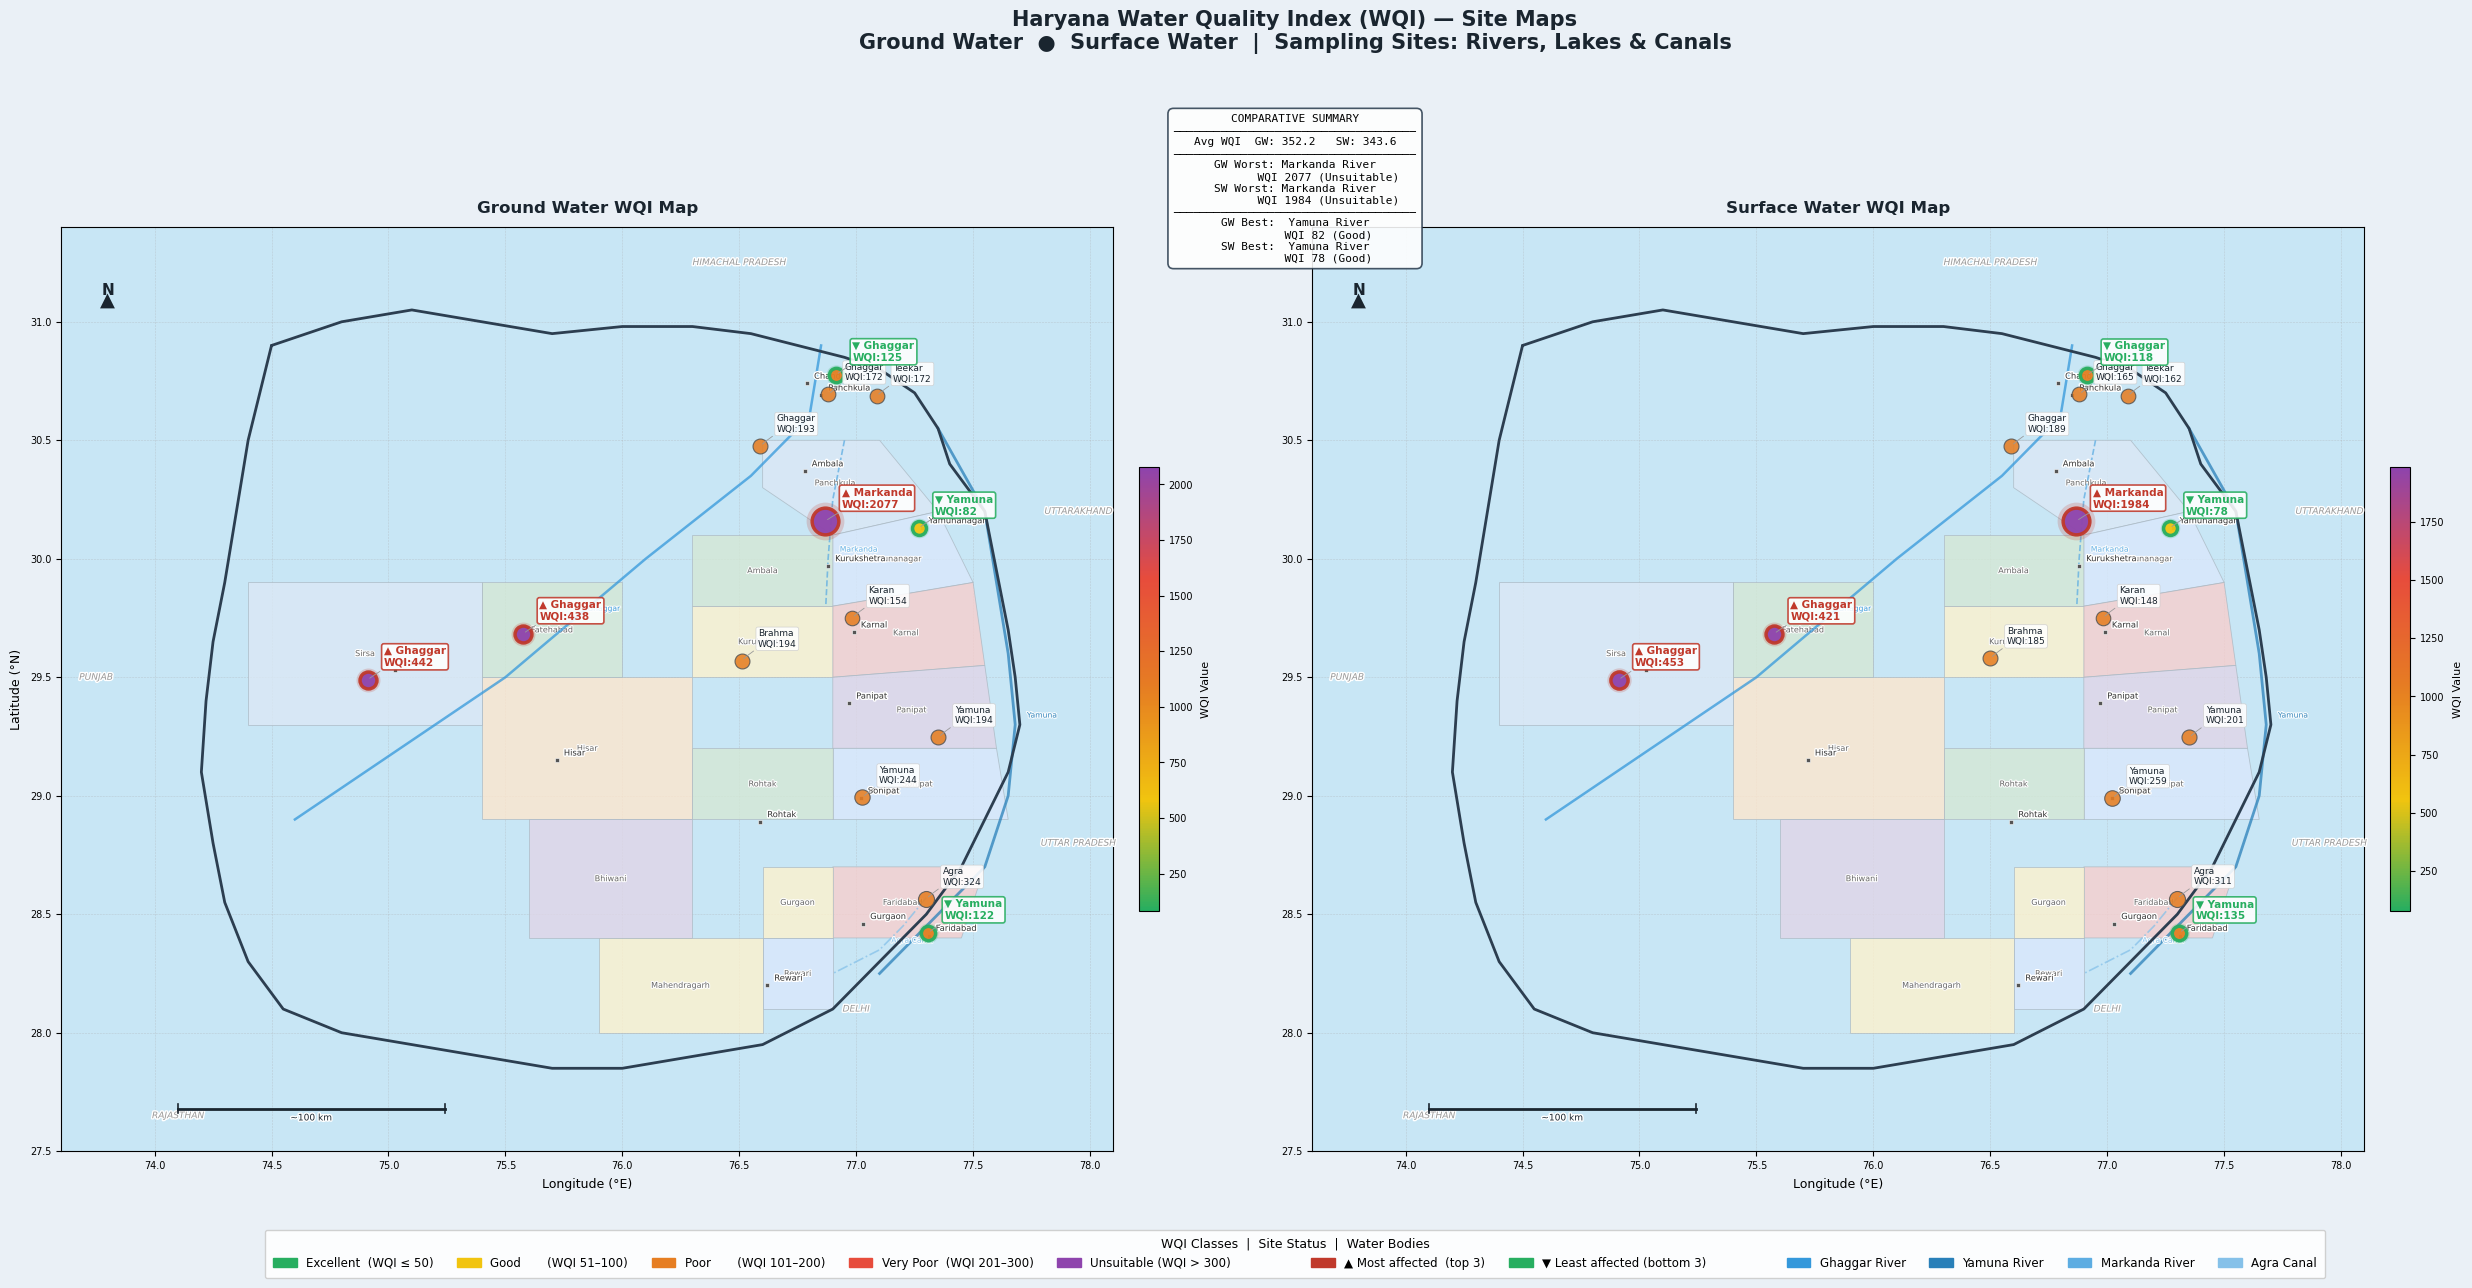

In [5]:
# =============================================================================
# HARYANA WATER QUALITY — COMBINED MAP NOTEBOOK
# Shows Ground Water + Surface Water WQI maps together for easy comparison
#
# HOW TO USE:
#   Option A — Run standalone with sample data (works immediately)
#   Option B — Pass your actual dataframes:
#       run_combined_maps(gw_df=your_gw_df, sw_df=your_sw_df)
#
# No extra libraries needed beyond matplotlib + numpy + pandas
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

# SHARED GEOGRAPHIC DATA- from project report

HARYANA_BOUNDARY = [
    (74.50,30.90),(74.80,31.00),(75.10,31.05),(75.40,31.00),
    (75.70,30.95),(76.00,30.98),(76.30,30.98),(76.55,30.95),
    (76.75,30.90),(76.95,30.85),(77.10,30.80),(77.25,30.70),
    (77.35,30.55),(77.40,30.40),(77.55,30.20),(77.60,29.95),
    (77.65,29.70),(77.68,29.50),(77.70,29.30),(77.65,29.10),
    (77.55,28.90),(77.45,28.70),(77.30,28.50),(77.10,28.30),
    (76.90,28.10),(76.60,27.95),(76.30,27.90),(76.00,27.85),
    (75.70,27.85),(75.40,27.90),(75.10,27.95),(74.80,28.00),
    (74.55,28.10),(74.40,28.30),(74.30,28.55),(74.25,28.80),
    (74.20,29.10),(74.22,29.40),(74.25,29.65),(74.30,29.90),
    (74.35,30.20),(74.40,30.50),(74.45,30.70),(74.50,30.90),
]

DISTRICTS = {
    "Panchkula":    [(76.60,30.50),(77.10,30.50),(77.35,30.20),(76.90,30.10),(76.60,30.30)],
    "Ambala":       [(76.30,30.10),(76.90,30.10),(76.90,29.80),(76.30,29.80)],
    "Yamunanagar":  [(76.90,30.10),(77.35,30.20),(77.50,29.90),(76.90,29.80)],
    "Kurukshetra":  [(76.30,29.80),(76.90,29.80),(76.90,29.50),(76.30,29.50)],
    "Karnal":       [(76.90,29.80),(77.50,29.90),(77.55,29.55),(76.90,29.50)],
    "Panipat":      [(76.90,29.50),(77.55,29.55),(77.60,29.20),(76.90,29.20)],
    "Sonipat":      [(76.90,29.20),(77.60,29.20),(77.65,28.90),(76.90,28.90)],
    "Rohtak":       [(76.30,29.20),(76.90,29.20),(76.90,28.90),(76.30,28.90)],
    "Faridabad":    [(76.90,28.70),(77.55,28.70),(77.45,28.40),(76.90,28.40)],
    "Gurgaon":      [(76.60,28.70),(76.90,28.70),(76.90,28.40),(76.60,28.40)],
    "Hisar":        [(75.40,29.50),(76.30,29.50),(76.30,28.90),(75.40,28.90)],
    "Sirsa":        [(74.40,29.90),(75.40,29.90),(75.40,29.30),(74.40,29.30)],
    "Fatehabad":    [(75.40,29.90),(76.00,29.90),(76.00,29.50),(75.40,29.50)],
    "Bhiwani":      [(75.60,28.90),(76.30,28.90),(76.30,28.40),(75.60,28.40)],
    "Mahendragarh": [(75.90,28.40),(76.60,28.40),(76.60,28.00),(75.90,28.00)],
    "Rewari":       [(76.60,28.40),(76.90,28.40),(76.90,28.10),(76.60,28.10)],
}

DISTRICT_COLORS = {
    "Panchkula":"#dce8f5","Ambala":"#d5e8d4","Yamunanagar":"#dae8fc",
    "Kurukshetra":"#fff2cc","Karnal":"#f8cecc","Panipat":"#e1d5e7",
    "Sonipat":"#dae8fc","Rohtak":"#d5e8d4","Faridabad":"#f8cecc",
    "Gurgaon":"#fff2cc","Hisar":"#ffe6cc","Sirsa":"#dce8f5",
    "Fatehabad":"#d5e8d4","Bhiwani":"#e1d5e7","Mahendragarh":"#fff2cc",
    "Rewari":"#dae8fc",
}

RIVERS = {
    "Ghaggar River": {"pts":[(76.85,30.90),(76.80,30.60),(76.55,30.35),(76.10,30.00),
                              (75.80,29.75),(75.50,29.50),(75.20,29.30),(74.90,29.10),(74.60,28.90)],
                      "color":"#3498db","lw":1.8,"ls":"-"},
    "Yamuna River":  {"pts":[(77.35,30.55),(77.55,30.20),(77.60,29.90),(77.65,29.60),
                              (77.68,29.30),(77.65,29.00),(77.55,28.70),(77.30,28.45),(77.10,28.25)],
                      "color":"#2980b9","lw":2.0,"ls":"-"},
    "Markanda River":{"pts":[(76.95,30.50),(76.90,30.25),(76.88,30.00),(76.87,29.80)],
                      "color":"#5dade2","lw":1.2,"ls":"--"},
    "Agra Canal":    {"pts":[(77.30,28.57),(77.20,28.45),(77.10,28.35),(76.90,28.25)],
                      "color":"#85c1e9","lw":1.2,"ls":"-."},
}

CITY_LABELS = {
    "Chandigarh":(30.74,76.79), "Ambala":(30.37,76.78),
    "Karnal":(29.69,76.99),     "Panipat":(29.39,76.97),
    "Sonipat":(28.99,77.02),    "Rohtak":(28.89,76.59),
    "Hisar":(29.15,75.72),      "Sirsa":(29.53,75.03),
    "Faridabad":(28.41,77.31),  "Gurgaon":(28.46,77.03),
    "Kurukshetra":(29.97,76.88),"Yamunanagar":(30.13,77.28),
    "Panchkula":(30.69,76.85),  "Rewari":(28.20,76.62),
}

NEIGHBOR_LABELS = [
    (76.50,31.25,"HIMACHAL PRADESH"),(77.95,30.20,"UTTARAKHAND"),
    (73.75,29.50,"PUNJAB"),(74.10,27.65,"RAJASTHAN"),
    (77.95,28.80,"UTTAR PRADESH"),(77.00,28.10,"DELHI"),
]

CLASS_COLORS = {
    "Excellent":"#27ae60","Good":"#f1c40f",
    "Poor":"#e67e22","Very Poor":"#e74c3c","Unsuitable":"#8e44ad","Unknown":"#95a5a6",
}

# SITE COORDINATES
def dms(deg, mins, secs, d):
    v = float(deg)+float(mins)/60+float(secs)/3600
    return round(-v if d in ('S','W') else v, 6)

COORDS = {
    # Ground Water
    "Ghaggar River(Site 1) (Ground Water)":   (dms(30,46,35,'N'), dms(76,54,51,'E')),
    "Ghaggar River(Site 2) (Ground Water)":   (dms(30,41,37,'N'), dms(76,52,52,'E')),
    "Ghaggar River(Site 3) (Ground Water)":   (30.4762, 76.5906),
    "Ghaggar River(Site 4) (Ground Water)":   (dms(29,41, 1,'N'), dms(75,34,33,'E')),
    "Ghaggar River(Site 5) (Ground Water)":   (dms(29,29,21,'N'), dms(74,54,38,'E')),
    "Yamuna River(Site 1) (Ground Water)":    (30.1290,  77.2674),
    "Yamuna River(Site 2) (Ground Water)":    (dms(29,14,48,'N'), dms(77,21, 5,'E')),
    "Yamuna River(Site 3) (Ground Water)":    (28.993,   77.027),
    "Yamuna River(Site 4) (Ground Water)":    (28.4215,  77.3076),
    "Markanda River(Site 1) (Ground Water)":  (30.1585,  76.8677),
    "Agra Canal(Site 1) (Ground Water)":      (dms(28,33,56,'N'), dms(77,17,60,'E')),
    "Teekar Taal(Site 3) (Ground Water)":     (30.6873,  77.0878),
    "Karan Lake (Site 1) (Ground Water)":     (dms(29,44,62,'N'), dms(76,58,58,'E')),
    "Brahma Sarovar(Site 2) (Ground Water)":  (29.57,    76.51),
    # Surface Water
    "Ghaggar River(Site 1) (Surface Water)":  (dms(30,46,30,'N'), dms(76,54,50,'E')),
    "Ghaggar River(Site 2) (Surface Water)":  (dms(30,41,39,'N'), dms(76,52,53,'E')),
    "Ghaggar River(Site 3) (Surface Water)":  (30.4766,  76.5905),
    "Ghaggar River(Site 4) (Surface Water)":  (dms(29,41, 0,'N'), dms(75,34,30,'E')),
    "Ghaggar River(Site 5) (Surface Water)":  (dms(29,29,21,'N'), dms(74,54,38,'E')),
    "Yamuna River(Site 1) (Surface Water)":   (30.1290,  77.2674),
    "Yamuna River(Site 2) (Surface Water)":   (dms(29,14,46,'N'), dms(77,21, 3,'E')),
    "Yamuna River(Site 3) (Surface Water)":   (28.990,   77.022),
    "Yamuna River(Site 4) (Surface Water)":   (28.4211,  77.3078),
    "Markanda River(Site 1) (Surface Water)": (30.1588,  76.8678),
    "Agra Canal(Site 1) (Surface Water)":     (dms(28,33,59,'N'), dms(77,17,60,'E')),
    "Teekar Taal(Site 3) (Surface Water)":    (30.6873,  77.0877),
    "Karan Lake (Site 1) (Surface Water)":    (dms(29,44,62,'N'), dms(76,58,54,'E')),
    "Brahma Sarovar(Site 2) (Surface Water)": (29.58,    76.50),
}

def get_class_color(wc):
    if not wc or str(wc)=="nan": return CLASS_COLORS["Unknown"]
    for k in CLASS_COLORS:
        if k.lower() in str(wc).lower(): return CLASS_COLORS[k]
    return CLASS_COLORS["Unknown"]

def match_site(name, water_type):
    wt = "ground water" if water_type=="ground" else "surface water"
    nl = str(name).lower().strip()
    best, score = None, 0
    for k in COORDS:
        if wt not in k.lower(): continue
        kw = set(k.lower().replace("(","").replace(")","").split())
        sw = set(nl.replace("(","").replace(")","").split())
        s  = len(kw & sw)
        if s > score: score=s; best=k
    return COORDS[best] if score>=2 else None

def wqi_to_class(w):
    if w<=50:   return "Excellent"
    elif w<=100: return "Good"
    elif w<=200: return "Poor"
    elif w<=300: return "Very Poor"
    else:        return "Unsuitable"

def prepare_site_df(df, wqi_col, class_col, water_type, top_n):
    site_col = next((c for c in ["site","Site","SITE"] if c in df.columns), None)
    if not site_col: return None, None, None
    agg = {wqi_col:"mean"}
    if class_col in df.columns:
        agg[class_col] = lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
    sdf = df.groupby(site_col).agg(agg).reset_index()
    sdf.columns = ["site","wqi_mean"] + (["wqi_class"] if class_col in df.columns else [])
    if "wqi_class" not in sdf.columns:
        sdf["wqi_class"] = sdf["wqi_mean"].apply(wqi_to_class)
    coords = [match_site(s, water_type) for s in sdf["site"]]
    sdf["coords"] = coords
    sdf = sdf[sdf["coords"].notna()].copy()
    sdf["lat"] = sdf["coords"].apply(lambda c: c[0])
    sdf["lon"] = sdf["coords"].apply(lambda c: c[1])
    sdf = sdf.sort_values("wqi_mean", ascending=False).reset_index(drop=True)
    most_aff  = set(sdf.head(top_n)["site"])
    least_aff = set(sdf.tail(top_n)["site"])
    return sdf, most_aff, least_aff

# SINGLE MAP AXES DRAWING FUNCTION
def draw_map_on_ax(ax, sdf, most_aff, least_aff, water_type, top_n, show_ylabel=True):
    """Draw a complete Haryana WQI map on the given axes object."""

    ax.set_facecolor("#c8e6f5")

    #  Neighbor labels 
    for lx,ly,lbl in NEIGHBOR_LABELS:
        ax.text(lx,ly,lbl,fontsize=6.5,color="#999",fontstyle="italic",
                ha="center",va="center",
                path_effects=[pe.withStroke(linewidth=2,foreground="white")])

    #  Districts 
    for dname, dpts in DISTRICTS.items():
        poly = MplPolygon(dpts, closed=True,
                          facecolor=DISTRICT_COLORS.get(dname,"#f0f0f0"),
                          edgecolor="#aab8c2", linewidth=0.6, alpha=0.78, zorder=2)
        ax.add_patch(poly)
        cx = np.mean([p[0] for p in dpts])
        cy = np.mean([p[1] for p in dpts])
        ax.text(cx,cy,dname,fontsize=5.8,color="#666",ha="center",va="center",zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5,foreground="white")])

    # State boundary 
    bx = [p[0] for p in HARYANA_BOUNDARY]+[HARYANA_BOUNDARY[0][0]]
    by = [p[1] for p in HARYANA_BOUNDARY]+[HARYANA_BOUNDARY[0][1]]
    ax.plot(bx,by,color="#2c3e50",linewidth=2.0,zorder=6,solid_capstyle="round")

    # Rivers 
    for rname, rv in RIVERS.items():
        rx=[p[0] for p in rv["pts"]]; ry=[p[1] for p in rv["pts"]]
        ax.plot(rx,ry,color=rv["color"],linewidth=rv["lw"],
                linestyle=rv["ls"],alpha=0.75,zorder=4)
        # River name label near midpoint
        mid = len(rx)//2
        ax.text(rx[mid]+0.05,ry[mid]+0.03,rname.replace(" River","").replace(" Canal"," Canal"),
                fontsize=5.5,color=rv["color"],alpha=0.9,zorder=4,
                path_effects=[pe.withStroke(linewidth=1.5,foreground="white")])

    #  City labels 
    for city,(clat,clon) in CITY_LABELS.items():
        ax.plot(clon,clat,"s",color="#555",markersize=3,zorder=5,
                markeredgecolor="white",markeredgewidth=0.4)
        ax.text(clon+0.03,clat+0.02,city,fontsize=6,color="#333",zorder=5,
                path_effects=[pe.withStroke(linewidth=2,foreground="white")])

    # WQI sites 
    wmin,wmax = sdf["wqi_mean"].min(), sdf["wqi_mean"].max()
    norm_wqi  = Normalize(vmin=wmin, vmax=wmax)
    wqi_cmap  = LinearSegmentedColormap.from_list(
        "wqi",["#27ae60","#f1c40f","#e67e22","#e74c3c","#8e44ad"])

    for _,row in sdf.iterrows():
        wv       = row["wqi_mean"]
        wc       = row.get("wqi_class","Unknown")
        sn       = row["site"]
        is_most  = sn in most_aff
        is_least = sn in least_aff
        lon,lat  = row["lon"],row["lat"]
        fcolor   = get_class_color(wc)
        nv       = norm_wqi(wv)
        ms       = 100 + nv*270

        # Glow ring
        if is_most or is_least:
            gc = "#c0392b" if is_most else "#27ae60"
            ax.scatter(lon,lat,s=ms*2.0,color=gc,alpha=0.2,zorder=7,linewidths=0)
            ax.scatter(lon,lat,s=ms,color=fcolor,edgecolors=gc,
                       linewidths=2.5,zorder=8,alpha=0.95)
        else:
            ax.scatter(lon,lat,s=ms,color=fcolor,edgecolors="#555",
                       linewidths=0.8,zorder=8,alpha=0.88)

        # Label
        short  = sn.split("(")[0].strip()
        short  = (short.replace(" River","").replace(" Canal","")
                       .replace(" Lake","").replace(" Sarovar","")
                       .replace(" Taal","").strip())
        prefix = "▲ " if is_most else ("▼ " if is_least else "")
        fc_lbl = "#c0392b" if is_most else ("#27ae60" if is_least else "#1a252f")
        fw     = "bold" if (is_most or is_least) else "normal"
        fs     = 7.5 if (is_most or is_least) else 6.5

        ax.annotate(
            f"{prefix}{short}\nWQI:{wv:.0f}",
            xy=(lon,lat), xytext=(lon+0.07, lat+0.06),
            fontsize=fs, color=fc_lbl, fontweight=fw, zorder=10,
            arrowprops=dict(arrowstyle="-",color="#999",lw=0.6,
                            connectionstyle="arc3,rad=0.1"),
            bbox=dict(boxstyle="round,pad=0.22",fc="white",
                      ec="#c0392b" if is_most else ("#27ae60" if is_least else "#ccc"),
                      alpha=0.88,
                      linewidth=1.2 if (is_most or is_least) else 0.5),
        )

    #  Colorbar 
    sm = ScalarMappable(cmap=wqi_cmap, norm=norm_wqi)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.48, pad=0.02, aspect=22)
    cbar.set_label("WQI Value", fontsize=8, labelpad=6)
    cbar.ax.tick_params(labelsize=7)

    # North arrow & scale bar 
    ax.annotate("N",  xy=(73.80,31.10),fontsize=11,fontweight="bold",
                color="#1a252f",ha="center",va="bottom",zorder=11)
    ax.annotate("▲",  xy=(73.80,31.05),fontsize=14,
                color="#1a252f",ha="center",va="bottom",zorder=11)
    ax.plot([74.10,75.24],[27.68,27.68],color="#1a252f",lw=2,zorder=11)
    ax.plot([74.10]*2,[27.66,27.70],color="#1a252f",lw=1.2,zorder=11)
    ax.plot([75.24]*2,[27.66,27.70],color="#1a252f",lw=1.2,zorder=11)
    ax.text(74.67,27.63,"~100 km",fontsize=6.5,ha="center",color="#1a252f",zorder=11,
            path_effects=[pe.withStroke(linewidth=2,foreground="white")])

    #  Axes formatting 
    ax.set_xlim(73.6, 78.1)
    ax.set_ylim(27.5, 31.4)
    ax.set_xticks(np.arange(74.0,78.5,0.5))
    ax.set_yticks(np.arange(27.5,31.5,0.5))
    ax.tick_params(labelsize=7)
    ax.set_xlabel("Longitude (°E)", fontsize=9, labelpad=5)
    if show_ylabel:
        ax.set_ylabel("Latitude (°N)", fontsize=9, labelpad=5)
    ax.grid(True,linestyle="--",linewidth=0.4,alpha=0.45,color="#aaa",zorder=1)

    return sm, wmin, wmax

# COMBINED MAP — MAIN FUNCTION

def run_combined_maps(gw_df, sw_df,
                      gw_wqi_col="wqi",    gw_class_col="wqi_class",
                      sw_wqi_col="WQI",    sw_class_col="WQI_Class",
                      top_n=3,
                      save_path="haryana_combined_wqi_map.png"):
    """
    Plot Ground Water and Surface Water WQI maps side by side.

    Parameters
    ----------
    gw_df         : Ground water DataFrame (must have 'site' + WQI columns)
    sw_df         : Surface water DataFrame
    gw_wqi_col    : WQI column name in gw_df  (default 'wqi')
    gw_class_col  : WQI class column in gw_df (default 'wqi_class')
    sw_wqi_col    : WQI column name in sw_df  (default 'WQI')
    sw_class_col  : WQI class column in sw_df (default 'WQI_Class')
    top_n         : how many most/least affected sites to highlight
    save_path     : output PNG path
    """

    # Prepare data 
    gw_sdf, gw_most, gw_least = prepare_site_df(gw_df, gw_wqi_col, gw_class_col, "ground", top_n)
    sw_sdf, sw_most, sw_least = prepare_site_df(sw_df, sw_wqi_col, sw_class_col, "surface", top_n)

    if gw_sdf is None or sw_sdf is None:
        print("Could not prepare data. Check site/WQI column names."); return

    #  Figure: 1 row × 2 cols 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 13))
    fig.patch.set_facecolor("#eaf0f6")

    #  Super title 
    fig.suptitle(
        "Haryana Water Quality Index (WQI) — Site Maps\n"
        "Ground Water  ●  Surface Water  |  Sampling Sites: Rivers, Lakes & Canals",
        fontsize=15, fontweight="bold", color="#1a252f", y=0.99
    )

    # Draw both maps 
    draw_map_on_ax(ax1, gw_sdf, gw_most, gw_least, "ground",  top_n, show_ylabel=True)
    draw_map_on_ax(ax2, sw_sdf, sw_most, sw_least, "surface", top_n, show_ylabel=False)

    ax1.set_title("Ground Water WQI Map", fontsize=12, fontweight="bold",
                  color="#1a252f", pad=10)
    ax2.set_title("Surface Water WQI Map", fontsize=12, fontweight="bold",
                  color="#1a252f", pad=10)

    #  Shared legend (below both maps) 
    legend_handles = [
        mpatches.Patch(color=CLASS_COLORS["Excellent"],  label="Excellent  (WQI ≤ 50)"),
        mpatches.Patch(color=CLASS_COLORS["Good"],       label="Good       (WQI 51–100)"),
        mpatches.Patch(color=CLASS_COLORS["Poor"],       label="Poor       (WQI 101–200)"),
        mpatches.Patch(color=CLASS_COLORS["Very Poor"],  label="Very Poor  (WQI 201–300)"),
        mpatches.Patch(color=CLASS_COLORS["Unsuitable"], label="Unsuitable (WQI > 300)"),
        mpatches.Patch(color="none",                     label=""),
        mpatches.Patch(color="#c0392b", label=f"▲ Most affected  (top {top_n})"),
        mpatches.Patch(color="#27ae60", label=f"▼ Least affected (bottom {top_n})"),
        mpatches.Patch(color="none",                     label=""),
        mpatches.Patch(color="#3498db", label="Ghaggar River"),
        mpatches.Patch(color="#2980b9", label="Yamuna River"),
        mpatches.Patch(color="#5dade2", label="Markanda River"),
        mpatches.Patch(color="#85c1e9", label="Agra Canal"),
    ]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=13, fontsize=8.5, framealpha=0.9,
               bbox_to_anchor=(0.5, 0.01),
               edgecolor="#ccc", borderpad=0.7,
               title="WQI Classes  |  Site Status  |  Water Bodies",
               title_fontsize=9)

    # Comparison summary box 
    gw_avg = gw_sdf["wqi_mean"].mean()
    sw_avg = sw_sdf["wqi_mean"].mean()
    gw_worst = gw_sdf.iloc[0]
    sw_worst = sw_sdf.iloc[0]
    gw_best  = gw_sdf.iloc[-1]
    sw_best  = sw_sdf.iloc[-1]

    summary = (
        f"COMPARATIVE SUMMARY\n"
        f"{'─'*36}\n"
        f"Avg WQI  GW: {gw_avg:.1f}   SW: {sw_avg:.1f}\n"
        f"{'─'*36}\n"
        f"GW Worst: {gw_worst['site'].split('(')[0].strip()[:20]}\n"
        f"          WQI {gw_worst['wqi_mean']:.0f} ({gw_worst['wqi_class']})\n"
        f"SW Worst: {sw_worst['site'].split('(')[0].strip()[:20]}\n"
        f"          WQI {sw_worst['wqi_mean']:.0f} ({sw_worst['wqi_class']})\n"
        f"{'─'*36}\n"
        f"GW Best:  {gw_best['site'].split('(')[0].strip()[:20]}\n"
        f"          WQI {gw_best['wqi_mean']:.0f} ({gw_best['wqi_class']})\n"
        f"SW Best:  {sw_best['site'].split('(')[0].strip()[:20]}\n"
        f"          WQI {sw_best['wqi_mean']:.0f} ({sw_best['wqi_class']})"
    )
    fig.text(0.5, 0.91, summary, ha="center", va="top",
             fontsize=8, family="monospace",
             bbox=dict(boxstyle="round,pad=0.5", fc="white",
                       ec="#2c3e50", alpha=0.88, linewidth=1.2))

    plt.tight_layout(rect=[0, 0.07, 1, 0.90])
    plt.savefig(save_path, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f" Combined map saved: {save_path}")

    # Console summary 
    for label, sdf, most_aff, least_aff in [
        ("GROUND WATER", gw_sdf, gw_most, gw_least),
        ("SURFACE WATER", sw_sdf, sw_most, sw_least)
    ]:
        print(f"\n{'─'*70}")
        print(f"  {label} SITE RANKINGS")
        print(f"{'─'*70}")
        print(f"  {'Site':<42} {'WQI':>8}  {'Class':<12}  Status")
        print(f"  {'─'*65}")
        for _, row in sdf.iterrows():
            flag = "🔴 MOST AFFECTED " if row["site"] in most_aff else \
                   ("🟢 LEAST AFFECTED" if row["site"] in least_aff else "")
            print(f"  {str(row['site']):<42} {row['wqi_mean']:>8.1f}"
                  f"  {str(row.get('wqi_class','—')):<12}  {flag}")

    plt.show()


# =============================================================================
#  SAMPLE DATA — replace with your actual dataframes
#    In your real notebooks: run_combined_maps(gw_df=df_from_gw_notebook,
#                                              sw_df=df_from_sw_notebook)
# =============================================================================

GW_SAMPLE = pd.DataFrame([
    {"site":"Ghaggar River(Site 1) (Ground Water)","wqi":125.2,"wqi_class":"Poor"},
    {"site":"Ghaggar River(Site 2) (Ground Water)","wqi":171.6,"wqi_class":"Poor"},
    {"site":"Ghaggar River(Site 3) (Ground Water)","wqi":193.3,"wqi_class":"Poor"},
    {"site":"Ghaggar River(Site 4) (Ground Water)","wqi":437.6,"wqi_class":"Unsuitable"},
    {"site":"Ghaggar River(Site 5) (Ground Water)","wqi":441.9,"wqi_class":"Unsuitable"},
    {"site":"Yamuna River(Site 1) (Ground Water)", "wqi":82.2, "wqi_class":"Good"},
    {"site":"Yamuna River(Site 2) (Ground Water)", "wqi":193.5,"wqi_class":"Poor"},
    {"site":"Yamuna River(Site 3) (Ground Water)", "wqi":243.7,"wqi_class":"Very Poor"},
    {"site":"Yamuna River(Site 4) (Ground Water)", "wqi":122.3,"wqi_class":"Poor"},
    {"site":"Markanda River(Site 1) (Ground Water)","wqi":2077.0,"wqi_class":"Unsuitable"},
    {"site":"Agra Canal(Site 1) (Ground Water)",   "wqi":324.4,"wqi_class":"Very Poor"},
    {"site":"Teekar Taal(Site 3) (Ground Water)",  "wqi":171.6,"wqi_class":"Poor"},
    {"site":"Karan Lake (Site 1) (Ground Water)",  "wqi":153.6,"wqi_class":"Poor"},
    {"site":"Brahma Sarovar(Site 2) (Ground Water)","wqi":193.5,"wqi_class":"Poor"},
])

SW_SAMPLE = pd.DataFrame([
    {"Site":"Ghaggar River(Site 1) (Surface Water)","WQI":118.4,"WQI_Class":"Poor"},
    {"Site":"Ghaggar River(Site 2) (Surface Water)","WQI":165.2,"WQI_Class":"Poor"},
    {"Site":"Ghaggar River(Site 3) (Surface Water)","WQI":188.7,"WQI_Class":"Poor"},
    {"Site":"Ghaggar River(Site 4) (Surface Water)","WQI":421.3,"WQI_Class":"Unsuitable"},
    {"Site":"Ghaggar River(Site 5) (Surface Water)","WQI":453.1,"WQI_Class":"Unsuitable"},
    {"Site":"Yamuna River(Site 1) (Surface Water)", "WQI":78.5, "WQI_Class":"Good"},
    {"Site":"Yamuna River(Site 2) (Surface Water)", "WQI":201.4,"WQI_Class":"Very Poor"},
    {"Site":"Yamuna River(Site 3) (Surface Water)", "WQI":258.9,"WQI_Class":"Very Poor"},
    {"Site":"Yamuna River(Site 4) (Surface Water)", "WQI":134.6,"WQI_Class":"Poor"},
    {"Site":"Markanda River(Site 1) (Surface Water)","WQI":1984.2,"WQI_Class":"Unsuitable"},
    {"Site":"Agra Canal(Site 1) (Surface Water)",   "WQI":310.7,"WQI_Class":"Very Poor"},
    {"Site":"Teekar Taal(Site 3) (Surface Water)",  "WQI":162.3,"WQI_Class":"Poor"},
    {"Site":"Karan Lake (Site 1) (Surface Water)",  "WQI":147.8,"WQI_Class":"Poor"},
    {"Site":"Brahma Sarovar(Site 2) (Surface Water)","WQI":185.2,"WQI_Class":"Poor"},
])

# RUN
run_combined_maps(
    gw_df          = GW_SAMPLE,
    sw_df          = SW_SAMPLE,
    gw_wqi_col     = "wqi",
    gw_class_col   = "wqi_class",
    sw_wqi_col     = "WQI",
    sw_class_col   = "WQI_Class",
    top_n          = 3,
    save_path      = "haryana_combined_wqi_map.png"
)

# =============================================================================
#  HOW TO USE WITH YOUR ACTUAL NOTEBOOKS:
#
# After running your GW regression/classification notebook, df has:
#   columns: site, wqi, wqi_class
#
# After running your SW regression/classification notebook, df has:
#   columns: Site, WQI, WQI_Class
#
# Simply call:
#   run_combined_maps(gw_df=gw_dataframe, sw_df=sw_dataframe)
# =============================================================================